In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

terms = pd.read_csv("05_terms.csv", index_col='DocNumber')

terms_df = terms.copy()
terms_df

,advice,author,cold,computing,encourage,examples,information,help,lesson,news,...,positions,proposal,recommend,research,sentiment,slides,suggestion,tip,tutorial,users
DocNumber,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,1,1
5,0,0,0,0,1,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,0,0,0,0,1,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,1
150,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
151,0,0,0,0,1,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0


In [2]:
terms_df.describe()

,advice,author,cold,computing,encourage,examples,information,help,lesson,news,...,positions,proposal,recommend,research,sentiment,slides,suggestion,tip,tutorial,users
count,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,...,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000
mean,0.150327,0.052288,0.058824,0.065359,0.339869,0.111111,0.065359,0.300654,0.111111,0.130719,...,0.071895,0.071895,0.450980,0.078431,0.052288,0.104575,0.078431,0.052288,0.104575,0.111111
std,0.358565,0.223337,0.236067,0.247971,0.475220,0.315302,0.247971,0.460048,0.315302,0.338200,...,0.259163,0.259163,0.499225,0.269732,0.223337,0.307010,0.269732,0.223337,0.307010,0.315302
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [3]:
# Are there any duplicated rows?
terms_df.duplicated().sum()


np.int64(53)

In [4]:
# What are the top 5 most common terms in the dataset?
term_totals = terms_df.sum().sort_values(ascending=False)
term_totals

recommend      69
encourage      52
help           46
advice         23
news           20
lesson         17
users          17
examples       17
slides         16
tutorial       16
research       12
suggestion     12
positions      11
proposal       11
information    10
computing      10
cold            9
author          8
sentiment       8
tip             8
opinion         8
dtype: int64

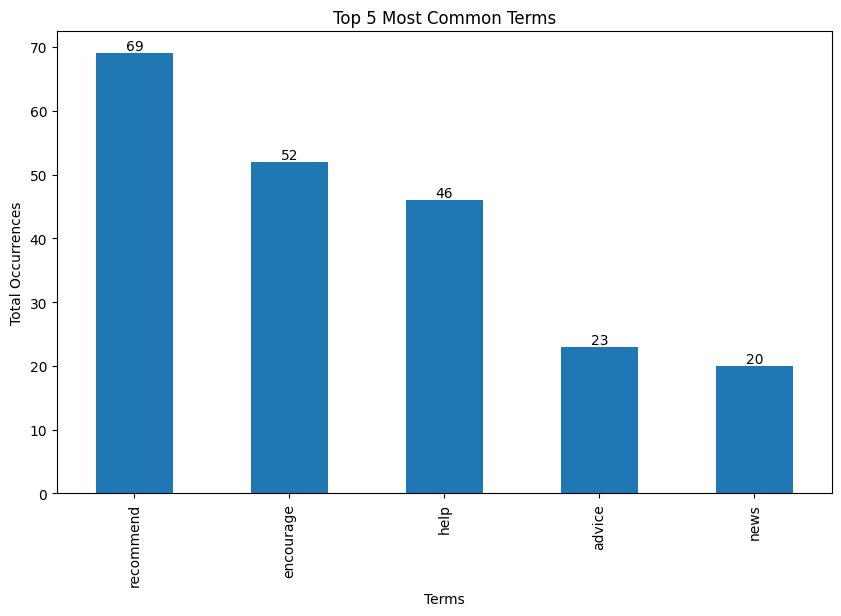

In [5]:
term_totals[:5].plot(kind='bar' , figsize=(10, 6))
plt.title("Top 5 Most Common Terms")
plt.xlabel("Terms")
plt.ylabel("Total Occurrences")
for index, value in enumerate(term_totals[:5]):
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.show()

In [6]:
terms_df.lesson.sum()

np.int64(17)

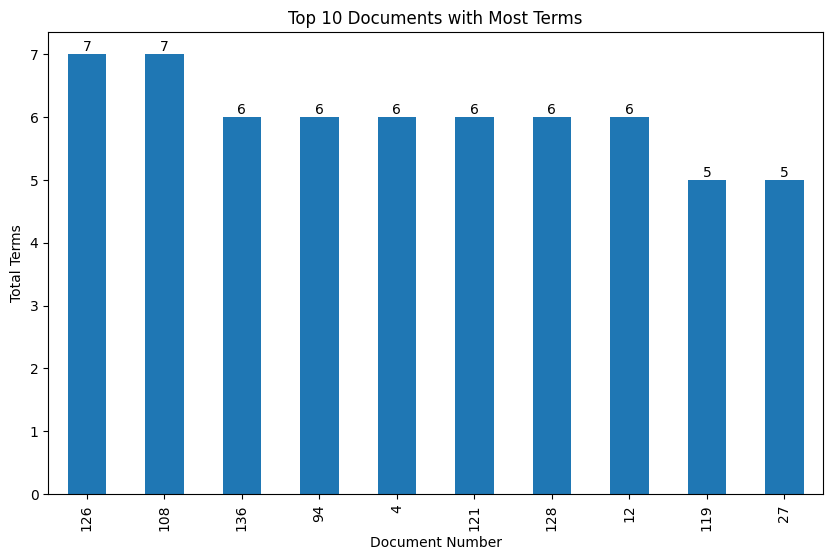

In [7]:
# Which document has the most terms?
doc_totals = terms_df.sum(axis=1).sort_values(ascending=False)
doc_totals[:10].plot(kind='bar', figsize=(10, 6))
plt.title("Top 10 Documents with Most Terms")
plt.xlabel("Document Number")
plt.ylabel("Total Terms")
for index, value in enumerate(doc_totals[:10]):
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.show()


In [8]:
# What documents contain more than 5 terms?
doc_totals[doc_totals > 5]

DocNumber
126    7
108    7
136    6
94     6
4      6
121    6
128    6
12     6
dtype: int64

In [9]:
# What is the average number of terms per document?
doc_totals.describe()

count    153.000000
mean       2.614379
std        1.526624
min        0.000000
25%        2.000000
50%        2.000000
75%        4.000000
max        7.000000
dtype: float64

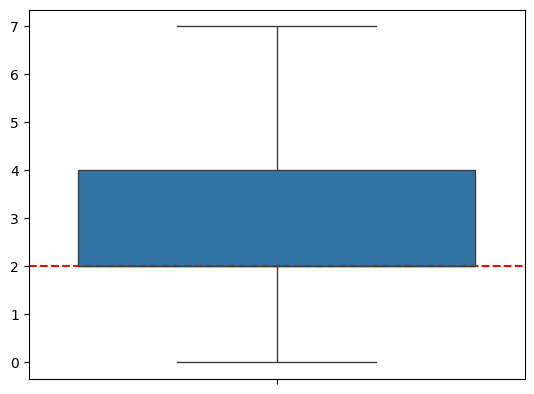

In [10]:
# What is the distribution of the number of terms per document with the median?
sns.boxplot(data=doc_totals)
plt.axhline(y=doc_totals.median(), color='red', linestyle='--')
plt.show()

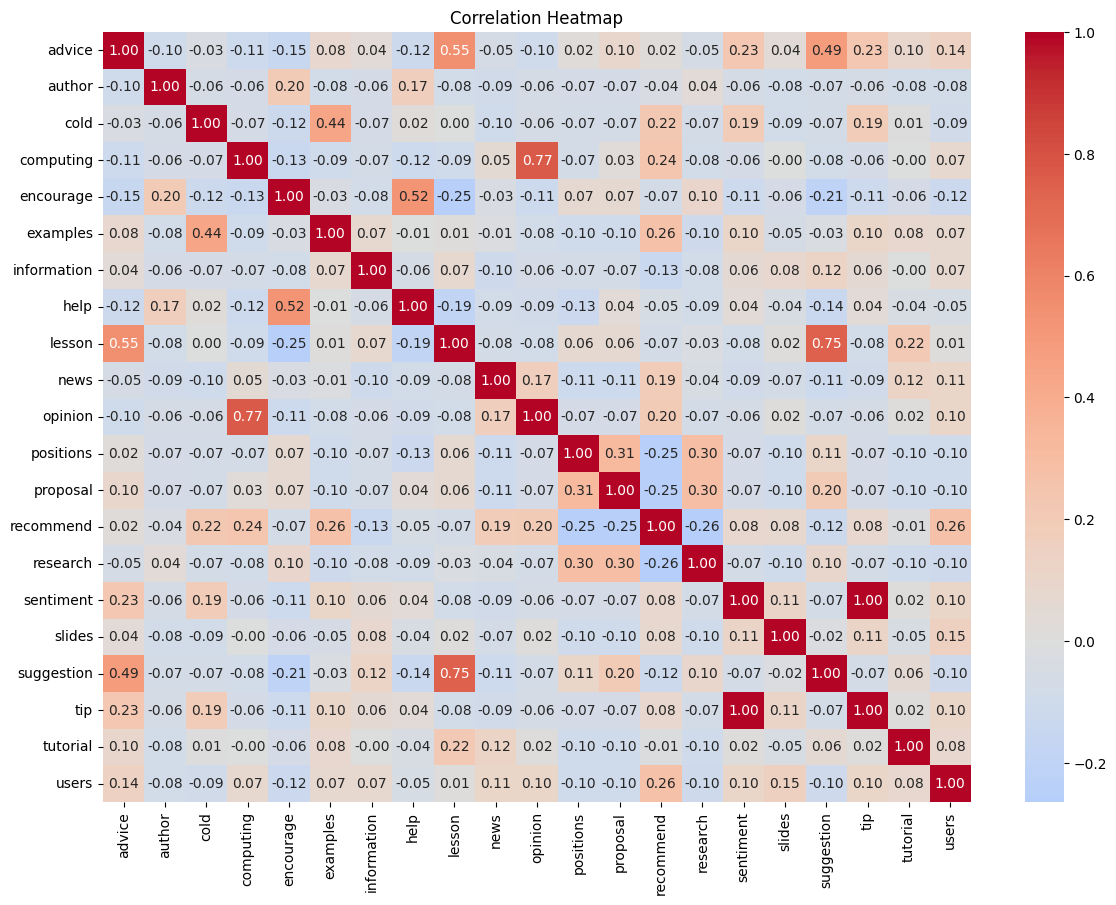

In [11]:
# Which are the most connected terms?
# Which are the least connected terms?
plt.figure(figsize=(14, 10))
sns.heatmap(terms_df.corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [12]:
# how many times does the terms "sentiment" and "tip" appear together in the dataset?
# terms_df[(terms_df['sentiment'] == 1) & (terms_df['tip'] == 1)].shape[0]
#terms_df[(terms_df['opinion'] == 1) & (terms_df['computing'] == 1)].shape[0]
# terms_df[(terms_df['suggestion'] == 1) & (terms_df['lesson'] == 1)].shape[0]


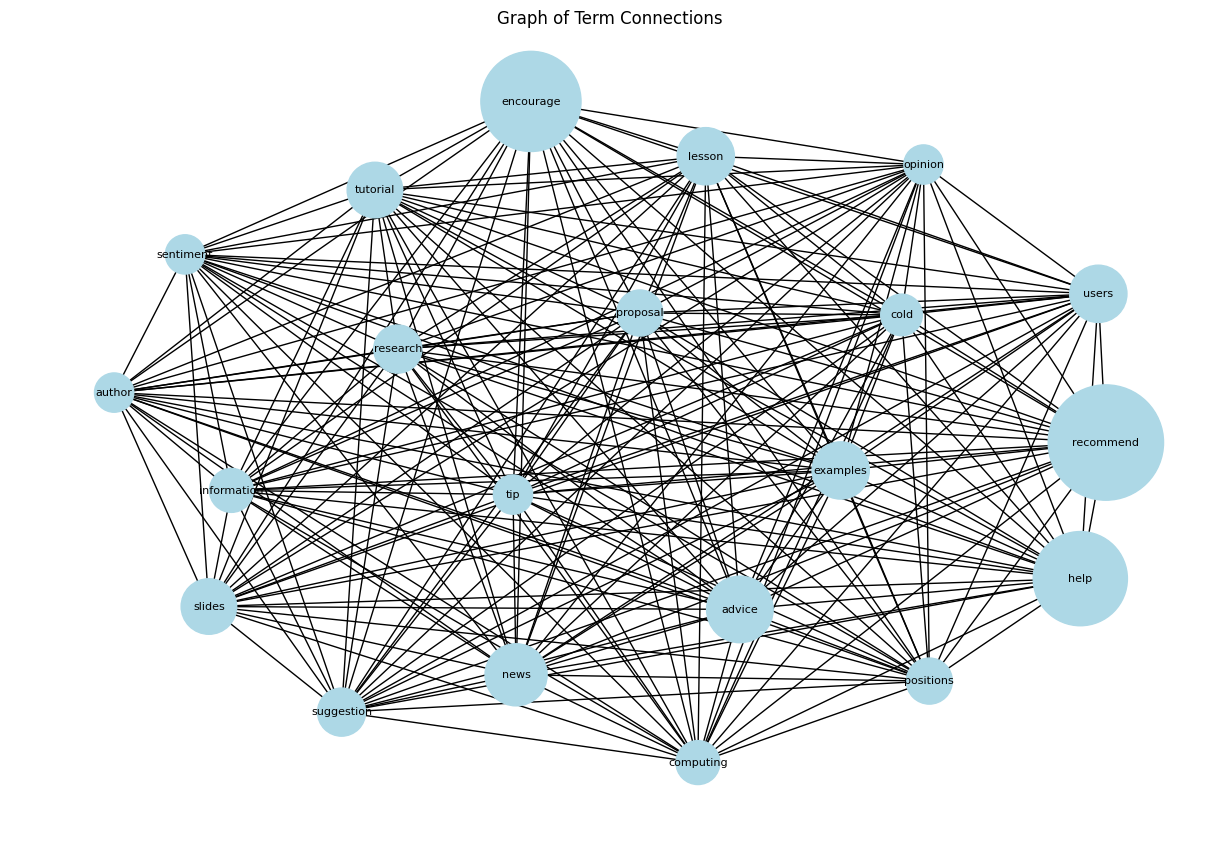

In [20]:
import networkx as nx

# Plot the graph that shows the links between the terms – how the terms are connected
G = nx.Graph()
for term in terms_df.columns:
    G.add_node(term)
for i in range(len(terms_df.columns)):
    for j in range(i + 1, len(terms_df.columns)):
        if terms_df.iloc[:, i].corr(terms_df.iloc[:, j]):  # Adjust the threshold as needed
            G.add_edge(terms_df.columns[i], terms_df.columns[j])

# Use graphics to enlarge the terms that appear the most, etc.
term_sizes = {term: term_totals[term] for term in terms_df.columns}
nx.set_node_attributes(G, term_sizes, 'size')



plt.figure(figsize=(12, 8))
nx.draw(G, with_labels=True, node_color='lightblue', edge_color='black', node_size=[term_sizes[term] * 100 for term in G.nodes()], font_size=8)
plt.title("Graph of Term Connections")
plt.show()